# Clasificación supervisada: algoritmos y evaluación

**Módulo 4 — Ciencia de Datos**

En este notebook vamos a recorrer un caso completo de **clasificación binaria**, integrando todos los conceptos vistos en la teoría:

1. **Regresión logística**: el algoritmo que adapta la lógica de la regresión lineal al problema de clasificar.
2. **k-NN**: un algoritmo basado en distancias, sin etapa de entrenamiento.
3. **Métricas de evaluación**: accuracy, matriz de confusión, precision, recall, F1.
4. **Validación cruzada**: cómo obtener una estimación robusta del desempeño.

Vamos a trabajar con el dataset **Breast Cancer Wisconsin**, que contiene mediciones de tumores y la etiqueta de si son benignos o malignos. Es un caso real donde la clasificación tiene consecuencias concretas: el tipo de error que comete el modelo importa.


## 1. Importación de librerías


In [1]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset y herramientas de scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Configuración estética
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

SEMILLA = 42

## 2. Carga y exploración del dataset

El dataset **Breast Cancer Wisconsin** contiene 569 observaciones, cada una correspondiente a un tumor del que se midieron 30 características numéricas (radio, textura, perímetro, área, etc.). La variable objetivo indica si el tumor es:

- **0**: maligno
- **1**: benigno

Este es un caso típico de **clasificación binaria**, donde los dos tipos de error tienen consecuencias muy distintas:

- Un **falso positivo** (predecir benigno cuando es maligno) podría retrasar un tratamiento.
- Un **falso negativo** (predecir maligno cuando es benigno) generaría procedimientos innecesarios.

Esta asimetría es clave: vamos a verla aparecer cuando discutamos las métricas.

> **Aclaración sobre la codificación:** en scikit-learn, la clase 0 es maligno y la 1 es benigno. Esto significa que el "positivo" en las métricas (lo que aparece como "clase 1") será **benigno**. Más adelante mostramos cómo invertir esta perspectiva para que el "positivo" sea el caso clínicamente relevante.


In [2]:
# Cargamos el dataset
datos = load_breast_cancer()

X = pd.DataFrame(datos.data, columns=datos.feature_names)
y = pd.Series(datos.target, name="diagnostico")

print(f"Cantidad de observaciones: {X.shape[0]}")
print(f"Cantidad de variables: {X.shape[1]}")
print(f"Clases posibles: {datos.target_names}")

Cantidad de observaciones: 569
Cantidad de variables: 30
Clases posibles: ['malignant' 'benign']


In [3]:
# Primeras filas
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Distribución de clases:
  Maligno (0): 212 casos
  Benigno (1): 357 casos
  Proporción de benignos: 62.74%


/tmp/ipykernel_4249/1930062786.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=["#D85A30", "#185FA5"])


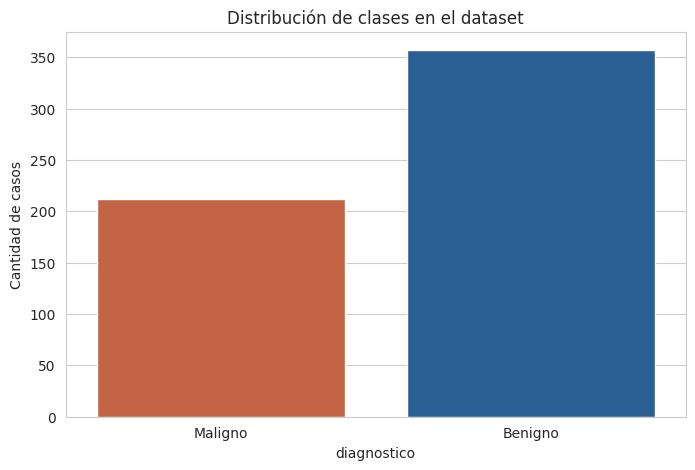

In [4]:
# Distribución de clases
conteo = y.value_counts()
print("Distribución de clases:")
print(f"  Maligno (0): {conteo[0]} casos")
print(f"  Benigno (1): {conteo[1]} casos")
print(f"  Proporción de benignos: {conteo[1] / len(y):.2%}")

# Gráfico
sns.countplot(x=y, palette=["#D85A30", "#185FA5"])
plt.title("Distribución de clases en el dataset")
plt.xticks([0, 1], ["Maligno", "Benigno"])
plt.ylabel("Cantidad de casos")
plt.show()

Las clases están razonablemente balanceadas (37% maligno, 63% benigno). No es un desbalance extremo, pero sí lo suficiente para que prestemos atención a métricas más allá del accuracy.


## 3. División en entrenamiento y prueba

Como vimos en el flujo de trabajo, no podemos evaluar el modelo con los mismos datos con los que lo entrenamos. Separamos el 80% para entrenamiento y el 20% para prueba.

El parámetro `stratify=y` asegura que la proporción de clases sea similar en ambos conjuntos.


In [5]:
# División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEMILLA
)

print(f"Entrenamiento: {X_train.shape[0]} casos")
print(f"Prueba: {X_test.shape[0]} casos")

Entrenamiento: 455 casos
Prueba: 114 casos


## 4. Escalado de variables

Las variables del dataset están en escalas muy distintas. Esto puede afectar tanto a la regresión logística (sobre todo cuando usa regularización) como a k-NN (cuyas distancias se distorsionan).

Aplicamos un **escalado estándar**: media 0, desvío 1.

> **Atención importante:** el escalador se ajusta **solamente con los datos de entrenamiento**, y luego se aplica también a prueba. Esto evita que información del conjunto de prueba se "filtre" al modelo (lo que se conoce como *data leakage*).


In [6]:
# Creamos y ajustamos el escalador con datos de entrenamiento
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)

# Aplicamos la misma transformación a los datos de prueba
X_test_esc = escalador.transform(X_test)

print("Variables escaladas correctamente.")

Variables escaladas correctamente.


# Parte 1: Regresión logística

## 5. Entrenamiento del modelo

Recordemos lo que hace la regresión logística por dentro:

1. Calcula una combinación lineal de las variables: $z = b_0 + b_1 x_1 + b_2 x_2 + \ldots + b_n x_n$
2. Aplica la sigmoide para transformar ese valor en una probabilidad: $P = \dfrac{1}{1 + e^{-z}}$
3. Si la probabilidad supera el umbral (0,5 por defecto), predice 1; si no, predice 0.

En código:


In [7]:
# Creamos y entrenamos el modelo
modelo_logistica = LogisticRegression(random_state=SEMILLA, max_iter=1000)
modelo_logistica.fit(X_train_esc, y_train)

print("Modelo de regresión logística entrenado correctamente.")

Modelo de regresión logística entrenado correctamente.


## 6. Interpretación de los coeficientes

Una ventaja de la regresión logística que mencionamos en la teoría es su **interpretabilidad**: los coeficientes nos dicen cómo influye cada variable.

- Coeficientes positivos: empujan hacia la clase 1 (benigno).
- Coeficientes negativos: empujan hacia la clase 0 (maligno).
- Cuanto mayor el valor absoluto, mayor el peso de la variable.


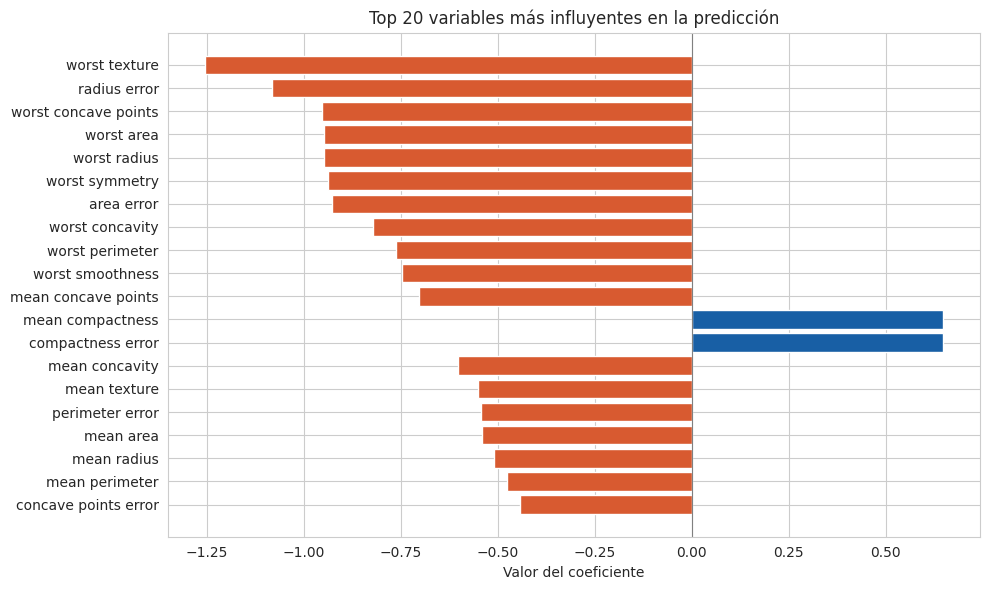

In [8]:
# Armamos un DataFrame con los coeficientes
coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": modelo_logistica.coef_[0]
})
coeficientes["magnitud"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values("magnitud", ascending=False)

# Top 20
top_20 = coeficientes.head(20)
colores_coef = ["#D85A30" if c < 0 else "#185FA5" for c in top_20["coeficiente"]]

plt.figure(figsize=(10, 6))
plt.barh(top_20["variable"], top_20["coeficiente"], color=colores_coef)
plt.xlabel("Valor del coeficiente")
plt.title("Top 20 variables más influyentes en la predicción")
plt.axvline(x=0, color="gray", linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Las variables en azul empujan hacia "benigno" cuando aumentan; las rojas, hacia "maligno". Este nivel de interpretabilidad es difícil de obtener con algoritmos más complejos y resulta especialmente valioso en contextos clínicos.


## 7. Probabilidades y umbral de decisión

Veamos la cadena completa que describimos en la teoría: variables → combinación lineal → sigmoide → probabilidad → umbral → clase.


In [9]:
# Probabilidades predichas (una columna por clase)
probabilidades = modelo_logistica.predict_proba(X_test_esc)

# Etiquetas predichas (con umbral 0,5)
y_pred_log = modelo_logistica.predict(X_test_esc)

# Primeros 10 casos
ejemplos = pd.DataFrame({
    "P(maligno)": probabilidades[:10, 0].round(3),
    "P(benigno)": probabilidades[:10, 1].round(3),
    "predicción": y_pred_log[:10],
    "real": y_test.values[:10]
})
print("Primeras 10 predicciones:")
ejemplos

Primeras 10 predicciones:


,P(maligno),P(benigno),predicción,real
0,1.000,0.000,0,0
1,0.000,1.000,1,1
2,0.994,0.006,0,0
3,0.466,0.534,1,1
4,1.000,0.000,0,0
5,0.008,0.992,1,1
6,0.000,1.000,1,1
7,1.000,0.000,0,0
8,1.000,0.000,0,0
9,1.000,0.000,0,0


Cuando la probabilidad de la clase 1 supera 0,5, el modelo predice 1; si no, predice 0. Este umbral se puede modificar si quisiéramos ser más o menos estrictos con una de las clases, algo que retomaremos más adelante.


# Parte 2: k-NN como contraste

## 8. Un algoritmo con lógica completamente distinta

Antes de pasar a evaluar el modelo de regresión logística en profundidad, vamos a entrenar también un k-NN sobre los mismos datos, para tener un punto de comparación.

Recordemos que k-NN tiene una lógica muy distinta:

- **No construye un modelo durante el entrenamiento**: solo guarda los datos en memoria.
- Frente a un caso nuevo, calcula la distancia a todas las observaciones del conjunto de entrenamiento.
- Asigna la etiqueta más frecuente entre los k vecinos más cercanos.

Por eso se lo llama **lazy learner**.


In [10]:
# Entrenamos k-NN con k=5
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_esc, y_train)

# Predicciones
y_pred_knn = modelo_knn.predict(X_test_esc)

# Accuracy de ambos modelos
acc_log = accuracy_score(y_test, y_pred_log)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Accuracy regresión logística: {acc_log:.4f} ({acc_log*100:.2f}%)")
print(f"Accuracy k-NN (k=5): {acc_knn:.4f} ({acc_knn*100:.2f}%)")

Accuracy regresión logística: 0.9825 (98.25%)
Accuracy k-NN (k=5): 0.9561 (95.61%)


Ambos modelos alcanzan buen desempeño, con valores similares. Pero como veremos enseguida, **el accuracy no nos cuenta toda la historia**: vamos a profundizar el análisis sobre la regresión logística para entender qué tipo de errores está cometiendo.


# Parte 3: Evaluación del modelo

## 9. Matriz de confusión

El accuracy nos dice cuántas predicciones acertó el modelo, pero no qué tipo de error comete. La **matriz de confusión** nos da ese detalle.

Para un problema binario tiene cuatro celdas:

- **Verdaderos positivos (VP)**: predichos como positivos, son positivos.
- **Verdaderos negativos (VN)**: predichos como negativos, son negativos.
- **Falsos positivos (FP)**: predichos como positivos, son negativos.
- **Falsos negativos (FN)**: predichos como negativos, son positivos.


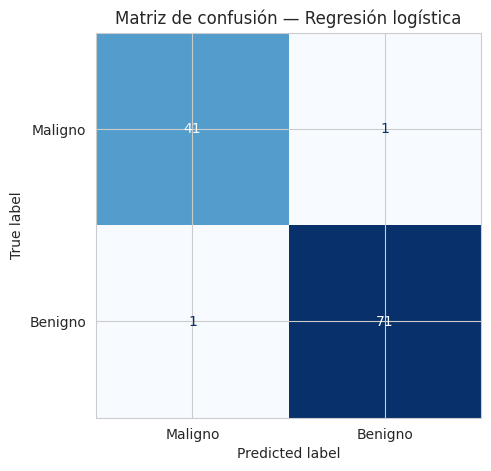

In [11]:
# Matriz de confusión para regresión logística
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    display_labels=["Maligno", "Benigno"],
    cmap="Blues", colorbar=False, ax=ax
)
plt.title("Matriz de confusión — Regresión logística")
plt.show()

**Cómo leerla:**

- Las filas son la realidad, las columnas son la predicción.
- La diagonal son los aciertos.
- Las celdas fuera de la diagonal son los errores.

En diagnóstico médico, los **falsos negativos** (predecir "benigno" cuando es maligno) son particularmente preocupantes: podrían retrasar un tratamiento necesario. Por eso, además del accuracy global, conviene mirar específicamente cuántos casos malignos se nos escapan.


## 10. Precision, recall y F1

A partir de la matriz de confusión se calculan métricas más finas. Recordemos las definiciones:

- **Precision**: de todo lo predicho como positivo, ¿cuánto era realmente positivo?
  Útil cuando el costo de los **falsos positivos** es alto.

- **Recall**: de todos los positivos reales, ¿cuántos detectó el modelo?
  Útil cuando el costo de los **falsos negativos** es alto.

- **F1-score**: media armónica entre precision y recall, útil cuando buscamos ambas en equilibrio.

> **Importante en este dataset:** scikit-learn por defecto considera "positivo" la clase 1 (benigno). Si nos interesa el desempeño sobre la clase clínicamente relevante (maligno), debemos mirar específicamente las métricas para esa clase.


In [12]:
# Reporte completo
print("Reporte de clasificación — Regresión logística:")
print(classification_report(
    y_test, y_pred_log,
    target_names=["Maligno", "Benigno"]
))

Reporte de clasificación — Regresión logística:
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**Lectura del reporte:**

- Cada fila es una clase, con sus métricas calculadas considerando esa clase como "positiva".
- `support` indica cuántos casos reales hay de esa clase en el conjunto de prueba.
- `macro avg` promedia las métricas dándole igual peso a cada clase.
- `weighted avg` promedia ponderando por el soporte de cada clase.

**Lectura para este problema concreto:**

Si nos importa detectar casos malignos (el escenario más realista clínicamente), miramos las métricas de la fila "Maligno":

- **Recall de Maligno**: porcentaje de tumores malignos reales que el modelo detectó. Es la métrica más crítica acá: queremos minimizar los casos malignos no detectados.
- **Precision de Maligno**: porcentaje de casos predichos como malignos que realmente lo eran. Si es muy baja, generamos muchas falsas alarmas.

**Ninguna métrica es universalmente mejor**: la elección depende del problema y de las consecuencias de cada tipo de error.


## 11. ¿Qué pasa si movemos el umbral?

Como vimos, las predicciones del modelo surgen de aplicar un umbral (0,5 por defecto) a las probabilidades. **Modificar ese umbral cambia el balance entre precision y recall** y es una herramienta práctica muy importante.

Vamos a ver cómo varían las métricas para detectar casos malignos al modificar el umbral.


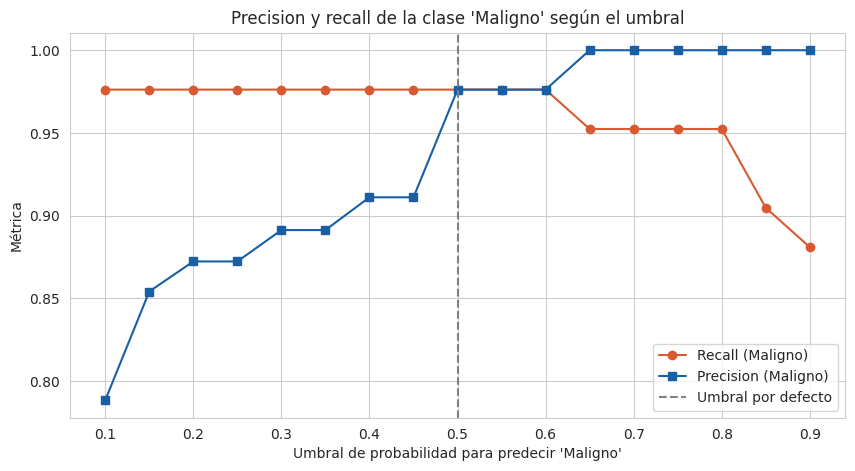

In [13]:
# Probabilidad de ser MALIGNO (clase 0)
prob_maligno = probabilidades[:, 0]

# Probamos distintos umbrales
umbrales = np.arange(0.1, 0.95, 0.05)
recalls_maligno = []
precisions_maligno = []

for u in umbrales:
    # Predecimos "maligno" si la probabilidad de maligno supera el umbral
    pred = (prob_maligno >= u).astype(int)
    # En la codificación original, 0 = maligno, así que invertimos
    pred = 1 - pred

    recalls_maligno.append(recall_score(y_test, pred, pos_label=0))
    precisions_maligno.append(precision_score(y_test, pred, pos_label=0, zero_division=0))

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(umbrales, recalls_maligno, marker="o", label="Recall (Maligno)", color="#D85A30")
plt.plot(umbrales, precisions_maligno, marker="s", label="Precision (Maligno)", color="#185FA5")
plt.axvline(x=0.5, color="gray", linestyle="--", label="Umbral por defecto")
plt.xlabel("Umbral de probabilidad para predecir 'Maligno'")
plt.ylabel("Métrica")
plt.title("Precision y recall de la clase 'Maligno' según el umbral")
plt.legend()
plt.show()

**Lo que se observa:**

- Si **bajamos el umbral** para clasificar como maligno (somos más estrictos), aumenta el **recall** (detectamos más malignos), pero baja la **precision** (más falsas alarmas).
- Si lo **subimos** (somos más laxos), pasa lo contrario.

Esto refleja el principio que vimos en la teoría mejorar una métrica suele empeorar otra. La elección del umbral no es una decisión técnica sino contextual, definida por las consecuencias prácticas de cada tipo de error.

En un contexto médico, probablemente preferiríamos un umbral más bajo: mejor convocar a algunas personas para estudios adicionales innecesarios que dejar un tumor maligno sin detectar.


# Parte 4: Validación cruzada

## 12. La limitación de una sola partición

Hasta acá evaluamos el modelo sobre una única partición train/test. Veamos por qué eso puede ser engañoso: repetimos la división con distintas semillas y observamos cómo varía el accuracy.


In [14]:
# Repetimos train/test 10 veces con distintas semillas
resultados = []
for semilla in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=semilla
    )
    esc = StandardScaler()
    X_tr_e = esc.fit_transform(X_tr)
    X_te_e = esc.transform(X_te)

    m = LogisticRegression(max_iter=1000, random_state=SEMILLA)
    m.fit(X_tr_e, y_tr)
    resultados.append(m.score(X_te_e, y_te))

print("Accuracies con 10 particiones distintas:")
for i, r in enumerate(resultados):
    print(f"  Semilla {i}: {r:.4f}")

print(f"\nMínimo: {min(resultados):.4f}")
print(f"Máximo: {max(resultados):.4f}")
print(f"Diferencia: {max(resultados) - min(resultados):.4f}")

Accuracies con 10 particiones distintas:
  Semilla 0: 0.9825
  Semilla 1: 0.9912
  Semilla 2: 0.9825
  Semilla 3: 0.9737
  Semilla 4: 0.9737
  Semilla 5: 0.9825
  Semilla 6: 0.9912
  Semilla 7: 0.9649
  Semilla 8: 0.9737
  Semilla 9: 1.0000

Mínimo: 0.9649
Máximo: 1.0000
Diferencia: 0.0351


Una sola partición da una estimación inestable del desempeño. La validación cruzada resuelve esto.

## 13. K-fold cross-validation

La validación cruzada divide los datos en k partes (tipicamente 5 o 10) y entrena el modelo k veces, cada vez usando una parte distinta como validación. Promediamos los resultados para obtener una estimación más robusta.

Vamos a usar **StratifiedKFold**, que mantiene la proporción de clases en cada fold.


In [15]:
# Necesitamos escalar antes de hacer cross-validation
# Para simplificar, escalamos sobre todo el dataset
# (en un proyecto real, esto se hace dentro de un Pipeline)
X_completo_esc = StandardScaler().fit_transform(X)

# Configuramos 5-fold estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

# Aplicamos cross-validation con regresión logística
modelo = LogisticRegression(max_iter=1000, random_state=SEMILLA)
scores = cross_val_score(modelo, X_completo_esc, y, cv=cv, scoring="accuracy")

print(f"Accuracies por fold: {[f'{s:.4f}' for s in scores]}")
print(f"Accuracy promedio: {scores.mean():.4f}")
print(f"Desvío estándar: {scores.std():.4f}")
print(f"\nLectura: el modelo tiene un accuracy de {scores.mean():.4f} ± {scores.std():.4f}")

Accuracies por fold: ['0.9737', '0.9474', '0.9649', '0.9912', '0.9912']
Accuracy promedio: 0.9737
Desvío estándar: 0.0166

Lectura: el modelo tiene un accuracy de 0.9737 ± 0.0166


La validación cruzada nos da no solo un valor de accuracy sino también una idea de su **variabilidad**. Un modelo con accuracy 0.97 ± 0.01 es más confiable que uno con 0.97 ± 0.05.

## 14. Cross-validation con distintas métricas

Una ventaja adicional: podemos pedir cross-validation no solo del accuracy sino de cualquier métrica relevante para nuestro problema.


In [16]:
# Cross-validation con distintas métricas
metricas = ["accuracy", "precision", "recall", "f1"]
resultados_metricas = {}

for metrica in metricas:
    scores = cross_val_score(modelo, X_completo_esc, y, cv=cv, scoring=metrica)
    resultados_metricas[metrica] = scores
    print(f"{metrica.capitalize():10s}: {scores.mean():.4f} ± {scores.std():.4f}")

Accuracy  : 0.9737 ± 0.0166
Precision : 0.9683 ± 0.0290
Recall    : 0.9916 ± 0.0112
F1        : 0.9794 ± 0.0127


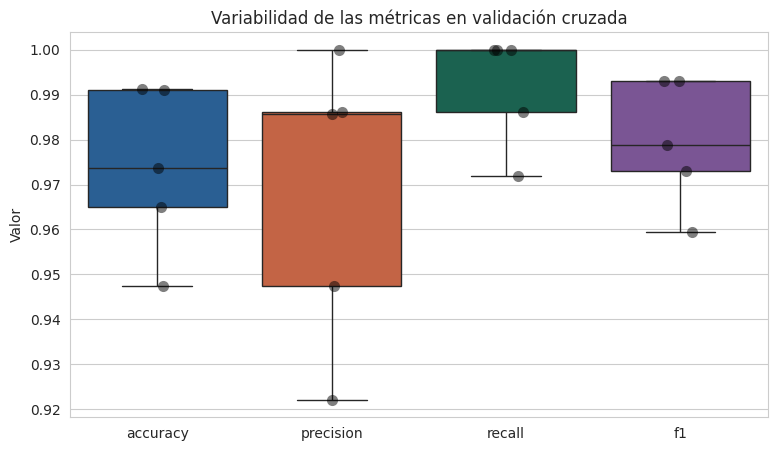

In [17]:
# Visualización de la variabilidad de cada métrica
df_metricas = pd.DataFrame(resultados_metricas)

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_metricas, palette=["#185FA5", "#D85A30", "#0F6E56", "#7C4A9E"])
sns.stripplot(data=df_metricas, color="black", size=8, alpha=0.5)
plt.ylabel("Valor")
plt.title("Variabilidad de las métricas en validación cruzada")
plt.show()

Estos boxplots muestran no solo el valor promedio de cada métrica, sino también su variabilidad entre folds. Métricas con cajas más chicas son más estables; cajas más grandes indican que el modelo se comporta de manera variable según la partición.

> **Nota técnica:** acá `precision`, `recall` y `f1` se calculan tomando la clase 1 (benigno) como positiva. Si nos interesa específicamente el desempeño sobre la clase maligna, podríamos invertir la codificación o usar `scoring="recall_macro"`, entre otras opciones.


## 15. Un experimento: por qué el accuracy puede engañar
Para cerrar, vamos a hacer un experimento que ilustra por qué el accuracy no alcanza con clases desbalanceadas.

Vamos a simular una situación común en problemas reales: un dataset donde la clase que nos interesa detectar es rara. Pensemos, por ejemplo, en detección de fraude bancario (donde el fraude representa una pequeña fracción de las transacciones), enfermedades poco frecuentes, o fallas en equipamiento industrial.

Vamos a generar un dataset sintético con make_classification de scikit-learn, donde podemos especificar exactamente la proporción de cada clase y la dificultad del problema. Después vamos a entrenar una regresión logística estándar sobre estos datos, siguiendo todas las buenas prácticas que vimos en el notebook.



In [20]:
from sklearn.datasets import make_classification

# Generamos un dataset sintético con clases desbalanceadas (5% positivos)
X_desb, y_desb = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=5,
    n_redundant=10,
    n_classes=2,
    weights=[0.95, 0.05],   # 5% positivos, 95% negativos
    flip_y=0.05,
    class_sep=0.8,
    random_state=SEMILLA
)

print(f"Total de casos: {len(y_desb)}")
print(f"Casos positivos: {y_desb.sum()}")
print(f"Casos negativos: {(y_desb == 0).sum()}")
print(f"Proporción de positivos: {y_desb.mean():.2%}")

Total de casos: 2000
Casos positivos: 149
Casos negativos: 1851
Proporción de positivos: 7.45%


Ahora entrenamos una regresión logística sobre este dataset, siguiendo el procedimiento estándar.

In [21]:
# Train/test split estratificado
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_desb, y_desb, test_size=0.3, stratify=y_desb, random_state=SEMILLA
)

# Escalado
esc_d = StandardScaler()
X_tr_d_esc = esc_d.fit_transform(X_tr_d)
X_te_d_esc = esc_d.transform(X_te_d)

# Entrenamos una regresión logística "estándar"
modelo_desb = LogisticRegression(max_iter=1000, random_state=SEMILLA)
modelo_desb.fit(X_tr_d_esc, y_tr_d)

# Predicciones
y_pred_desb = modelo_desb.predict(X_te_d_esc)

# Métricas
print("Regresión logística entrenada sobre el dataset desbalanceado:")
print(f"  Accuracy: {accuracy_score(y_te_d, y_pred_desb):.4f}")
print(f"  Precision (clase positiva): {precision_score(y_te_d, y_pred_desb, zero_division=0):.4f}")
print(f"  Recall (clase positiva):    {recall_score(y_te_d, y_pred_desb, zero_division=0):.4f}")
print(f"  F1 (clase positiva):        {f1_score(y_te_d, y_pred_desb, zero_division=0):.4f}")

Regresión logística entrenada sobre el dataset desbalanceado:
  Accuracy: 0.9250
  Precision (clase positiva): 0.0000
  Recall (clase positiva):    0.0000
  F1 (clase positiva):        0.0000


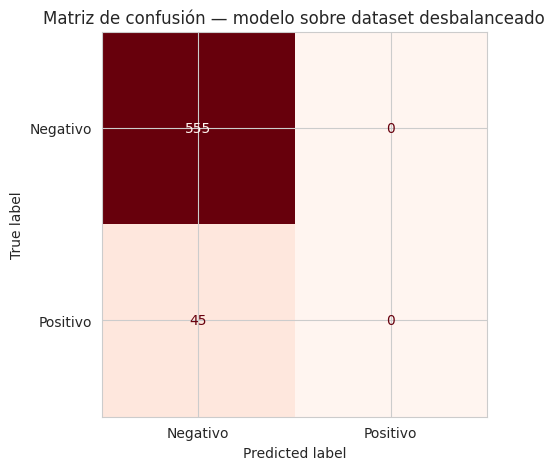

Casos positivos reales en el test: 45
Casos positivos detectados por el modelo: 0


In [22]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te_d, y_pred_desb,
    display_labels=["Negativo", "Positivo"],
    cmap="Reds", colorbar=False, ax=ax
)
plt.title("Matriz de confusión — modelo sobre dataset desbalanceado")
plt.show()

# Información adicional
print(f"Casos positivos reales en el test: {(y_te_d == 1).sum()}")
print(f"Casos positivos detectados por el modelo: {((y_pred_desb == 1) & (y_te_d == 1)).sum()}")

**Acá está el punto:**

El modelo tiene un accuracy altísimo, arriba del 94%. Si solo miráramos esa métrica, diríamos que está funcionando muy bien.

Pero si miramos la matriz de confusión, vemos algo perturbador: el modelo **prácticamente no detecta ningún caso positivo**. Todos los positivos reales caen en la celda de los falsos negativos. La precision y el recall sobre la clase positiva colapsan a cero o cerca de cero.

**¿Por qué pasa esto?**

Porque cuando una clase es muy minoritaria, predecir "negativo" casi siempre es una apuesta segura: el modelo se equivoca poco en términos relativos. La función de pérdida que minimiza durante el entrenamiento **no distingue entre tipos de error**, así que se "conforma" con acertar la enorme mayoría de los casos negativos, aun a costa de fallar sistemáticamente con los positivos. Es una estrategia racional para minimizar el error global, pero **completamente inútil** para el propósito real del modelo.

> **Esto es lo crítico:** un modelo entrenado correctamente, con buenas prácticas, puede ser **inútil para el propósito real** si solo lo evaluamos con accuracy. Y este no es un caso construido artificialmente: pasa todo el tiempo en problemas reales como detección de fraude, diagnóstico de enfermedades raras o detección de defectos en producción.

**Conclusión práctica:**

Con clases desbalanceadas hay que:
1. **Mirar las métricas adecuadas** (recall, precision o F1 sobre la clase de interés), nunca solo accuracy.
2. **Considerar estrategias específicas** que verán en materias más avanzadas: ajuste de pesos por clase (`class_weight="balanced"` en scikit-learn), modificación del umbral, técnicas de sobremuestreo o submuestreo, métricas como AUC-ROC.

Por ahora, lo importante es que se queden con la idea: **el accuracy puede mentir, y los modelos pueden parecer buenos cuando en realidad fallan donde más importa**.

## 16. Síntesis del notebook

Recorrimos un caso completo de clasificación binaria, conectando cada paso con el material teórico:

| Sección | Concepto de la teoría |
|---|---|
| Carga del dataset y partición train/test | Flujo de trabajo en clasificación |
| Escalado solo con train | Buenas prácticas de preprocesamiento |
| Regresión logística | Combinación lineal + sigmoide + umbral |
| Coeficientes | Interpretabilidad del modelo |
| k-NN como contraste | Algoritmo basado en instancias |
| Matriz de confusión | Tipos de error que comete el modelo |
| Precision, recall, F1 | Métricas más informativas que accuracy |
| Modificación del umbral | Trade-off entre precision y recall |
| Repetición de train/test | Limitación de una sola partición |
| Cross-validation | Estimación robusta del desempeño |
| Cross-validation con varias métricas | Análisis multidimensional |
| Experimento de desbalance | Por qué el accuracy puede engañar |

En el próximo notebook vamos a movernos al terreno **no supervisado** con PCA y k-means, junto con sus propias métricas de evaluación.
